In [3]:
from pathlib import Path
from typing import Final

import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
import polars as pl
from joblib import Memory

from src.config.constants import Product
from src.processing.dataset_spec import DatasetSpec
from src.processing.orderbook import OrderBookDataProcessor, OrderBookDataset
from src.research.black_scholes import BlackScholesCall

memory: Final[Memory] = Memory("./cache")

BS: Final[BlackScholesCall] = BlackScholesCall(r=0, T_days=5)

VELVETFRUIT_EXTRACT = Product.VELVETFRUIT_EXTRACT
VEV_OPTIONS_PREF: Final[str] = "VEV_"
ROUND: Final[int] = 3
DAY: Final[int] = 0

DATASET: Final[DatasetSpec] = DatasetSpec(ROUND, DAY)
ORDERBOOK_CSV_FILE: Final[Path] = DATASET.prices()
RAW_UNDERLYING_ORDERBOOK_DATA: Final[OrderBookDataProcessor] = OrderBookDataset(
    ORDERBOOK_CSV_FILE
).for_product(VELVETFRUIT_EXTRACT)
RAW_OPTIONS_ORDERBOOK_DATA: Final[OrderBookDataProcessor] = OrderBookDataset(
    ORDERBOOK_CSV_FILE
).for_product("VEV_")


@memory.cache
def get_iv_series(
    microprices: npt.NDArray[np.float64],
    strike_prices: npt.NDArray[np.float64],
    spot_prices: npt.NDArray[np.float64],
) -> pl.Series:
    IV_data = [
        BS.implied_vol(C_market=c, K=k, S=s)
        for c, k, s in zip(microprices, strike_prices, spot_prices)
    ]

    return pl.Series(name="IV", values=IV_data)


def get_quadratic_coeffs(x_data: npt.NDArray, y_data: npt.NDArray) -> npt.NDArray:
    return np.polyfit(x_data, y_data, 2)


underlying_orderbook_data: Final[pl.DataFrame] = (
    RAW_UNDERLYING_ORDERBOOK_DATA.clean()
    .build()
    .select(["timestamp", "mid_price"])
    .rename({"mid_price": "spot_price"})
)
options_orderbook_data: pl.DataFrame = (
    (
        RAW_OPTIONS_ORDERBOOK_DATA.clean()
        .add_strikes_col()
        .add_microstructure_features()
        .add_price_features()
        .add_depth_features()
        .build()
    )
    .join(underlying_orderbook_data, on="timestamp", how="left")
    .with_columns(
        (pl.col("spot_price") / pl.col("strike_price")).log().alias("log_moneyness")
    )
)

IV_SERIES: Final[pl.Series] = get_iv_series(
    options_orderbook_data["microprice"].to_numpy(),
    options_orderbook_data["strike_price"].to_numpy(),
    options_orderbook_data["spot_price"].to_numpy(),
)

options_orderbook_data: pl.DataFrame = options_orderbook_data.with_columns(
    IV_SERIES
).drop_nulls("IV")
options_features_data: Final[pl.DataFrame] = options_orderbook_data.select(
    ["timestamp", "strike_price", "spot_price", "mid_price", "log_moneyness", "IV"]
)

In [4]:
options_orderbook_data

timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,strike_price,spread,imbalance,midprice_dev,log_returns,future_log_returns,microprice,microprice_dev,depth,spot_price,log_moneyness,IV
i64,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,i64,i64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64
0,"""VEV_5400""",22,25,null,null,null,null,24,25,null,null,null,null,23.0,5400,2,0.0,-235.83025,null,-3.828641,23.0,0.0,50,5250.0,-0.028171,0.303428
0,"""VEV_6500""",0,16,null,null,null,null,1,16,null,null,null,null,0.5,6500,1,0.0,-258.33025,-3.828641,2.833213,0.5,0.0,32,5250.0,-0.213574,0.677302
0,"""VEV_5500""",8,25,null,null,null,null,9,25,null,null,null,null,8.5,5500,1,0.0,-250.33025,2.833213,2.479993,8.5,0.0,50,5250.0,-0.04652,0.303375
0,"""VEV_5200""",100,19,null,null,null,null,103,6,104,13,null,null,101.5,5200,3,0.0,-157.33025,2.479993,-0.649767,102.28,0.78,25,5250.0,0.009569,0.305918
0,"""VEV_5300""",52,6,51,19,null,null,54,25,null,null,null,null,53.0,5300,2,0.0,-205.83025,-0.649767,2.649781,52.387097,-0.612903,31,5250.0,-0.009479,0.303469
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
999900,"""VEV_5000""",247,23,null,null,null,null,253,10,254,13,null,null,250.0,5000,6,0.0,-8.83025,1.671313,1.604626,251.181818,1.181818,33,5244.0,0.047647,0.299366
999900,"""VEV_4000""",1234,14,1231,18,null,null,1254,14,1257,18,null,null,1244.0,4000,20,0.0,985.16975,1.604626,-2.026221,1244.0,0.0,28,5244.0,0.27079,0.423225
999900,"""VEV_5100""",162,23,null,null,null,null,166,10,167,13,null,null,164.0,5100,4,0.0,-94.83025,-2.026221,-5.793014,164.787879,0.787879,33,5244.0,0.027844,0.292519


In [5]:
coeffs = get_quadratic_coeffs(
    options_features_data["log_moneyness"].to_numpy(),
    options_features_data["IV"].to_numpy(),
)
poly = np.poly1d(coeffs)
options_features_data = options_features_data.with_columns(
    pl.Series("fair_IV", poly(options_features_data["log_moneyness"].to_numpy()))
).with_columns((pl.col("IV") - pl.col("fair_IV")).alias("IV_dev"))

print(f"a={coeffs[0]}, b={coeffs[1]}, c={coeffs[2]}")

a=5.072685908964969, b=-0.6074819778933004, c=0.2917365991488423


In [6]:
fair_prices = []

for K, S, sigma in options_features_data.select(
    ["strike_price", "spot_price", "fair_IV"]
).iter_rows():
    fair_prices.append(BS.call_price(K, S, sigma))

In [7]:
options_features_data = options_features_data.with_columns(
    pl.Series("fair_price", fair_prices)
).with_columns((pl.col("fair_price") - pl.col("mid_price")).alias("fair_price_dev"))

options_features_data

timestamp,strike_price,spot_price,mid_price,log_moneyness,IV,fair_IV,IV_dev,fair_price,fair_price_dev
i64,i64,f64,f64,f64,f64,f64,f64,f64,f64
0,5400,5250.0,23.0,-0.028171,0.303428,0.312876,-0.009447,24.730807,1.730807
0,6500,5250.0,0.5,-0.213574,0.677302,0.652864,0.024438,0.345219,-0.154781
0,5500,5250.0,8.5,-0.04652,0.303375,0.330975,-0.0276,11.655196,3.155196
0,5200,5250.0,101.5,0.009569,0.305918,0.286388,0.01953,97.694319,-3.805681
0,5300,5250.0,53.0,-0.009479,0.303469,0.297951,0.005518,51.076573,-1.923427
…,…,…,…,…,…,…,…,…,…
999900,5000,5244.0,250.0,0.047647,0.299366,0.274308,0.025058,248.995134,-1.004866
999900,4000,5244.0,1244.0,0.27079,0.423225,0.499203,-0.075978,1244.000095,0.000095
999900,5100,5244.0,164.0,0.027844,0.292519,0.278755,0.013764,162.439062,-1.560938


In [13]:
coeffs = get_quadratic_coeffs(
    options_features_data["log_moneyness"].to_numpy(),
    options_features_data["IV"].to_numpy(),
)
poly = np.poly1d(coeffs)

print(f"a={coeffs[0]}, b={coeffs[1]}, c={coeffs[2]}")
print(list(map(float, coeffs)))

a=5.072685908964969, b=-0.6074819778933004, c=0.2917365991488423
[5.072685908964969, -0.6074819778933004, 0.2917365991488423]


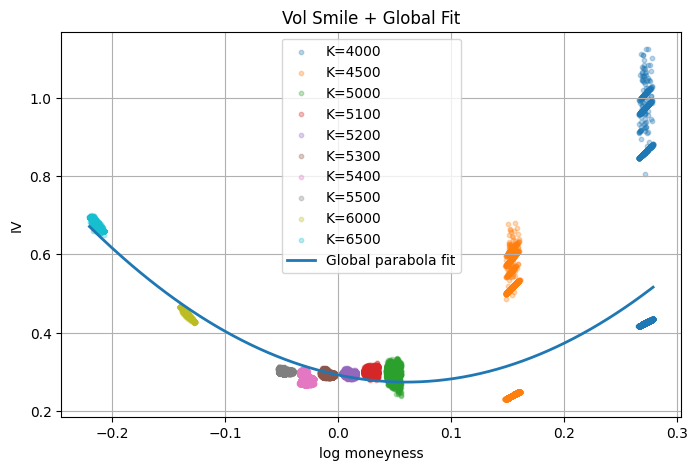

In [9]:
plt.figure(figsize=(8, 5))

for strike in options_features_data["strike_price"].unique().to_list():
    sub = options_features_data.filter(pl.col("strike_price") == strike)

    plt.scatter(
        sub["log_moneyness"].to_numpy(),
        sub["IV"].to_numpy(),
        label=f"K={strike}",
        alpha=0.3,
        s=10,
    )

x_fit = np.linspace(
    options_features_data["log_moneyness"].min(),
    options_features_data["log_moneyness"].max(),
    200,
)
y_fit = poly(x_fit)
plt.plot(x_fit, y_fit, linewidth=2, label="Global parabola fit")

plt.xlabel("log moneyness")
plt.ylabel("IV")
plt.title("Vol Smile + Global Fit")
plt.grid()
plt.legend()

plt.show()

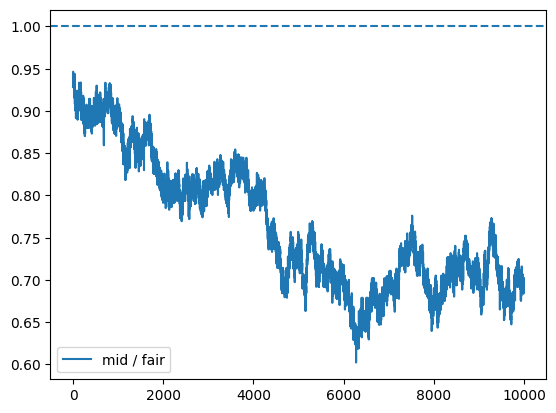

In [10]:
df = options_features_data.filter(pl.col("strike_price") == 5400)
mid = df["mid_price"].to_numpy()
fair = df["fair_price"].to_numpy()

ratio = mid / fair

plt.plot(ratio, label="mid / fair")
plt.axhline(1.0, linestyle="--")
plt.legend()